* Análise de Performance de Jogadores – Temporada 2025/2026

 Dataset: Kaggle – Players Data 2025/2026

Este projeto tem como objetivo analisar o desempenho de jogadores da temporada 2025/2026, identificando padrões ofensivos e defensivos, comparando ligas e construindo um modelo simplificado de avaliação de performance.

In [ ]:
# Importando libs
import pandas as pd # manipulação e análse de dados
import matplotlib.pyplot as plt # visualização de dados
import seaborn as sns # visualização de dados

# pip install pandas matplotlib seaborn

* Carregando dados

In [2]:
# Filtrar colunas
colunas_desejadas = ["Player", "Nation", "Pos", "Squad", "Comp", "Age", "Gls", "Ast", "G+A", "Saves", "Tkl+Int", "KP" ]

# Ler dados de arquivo csv
df = pd.read_csv(r"data\players_data-2025_2026.csv", usecols=colunas_desejadas)
df.head()
df.info()
df.describe()
df.isnull().sum()

# Visualizar dados
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2433 entries, 0 to 2432
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   2433 non-null   object 
 1   Nation   2432 non-null   object 
 2   Pos      2433 non-null   object 
 3   Squad    2433 non-null   object 
 4   Comp     2433 non-null   object 
 5   Age      2431 non-null   float64
 6   Gls      2433 non-null   int64  
 7   Ast      2433 non-null   int64  
 8   G+A      2433 non-null   int64  
 9   KP       2433 non-null   int64  
 10  Tkl+Int  2433 non-null   int64  
 11  Saves    150 non-null    float64
dtypes: float64(2), int64(5), object(5)
memory usage: 228.2+ KB


,Player,Nation,Pos,Squad,Comp,Age,Gls,Ast,G+A,KP,Tkl+Int,Saves
0,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25.0,4,3,7,19,40,NaN
1,Zach Abbott,eng ENG,DF,Nott'ham Forest,eng Premier League,19.0,0,0,0,0,1,NaN
2,Jones El-Abdellaoui,ma MAR,"FW,MF",Celta Vigo,es La Liga,20.0,2,0,2,3,2,NaN
3,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,2,0,2,8,35,NaN
4,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,32.0,0,0,0,6,13,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2428,Yanis Zouaoui,dz ALG,DF,Le Havre,fr Ligue 1,31.0,0,1,1,22,33,NaN
2429,Igor Zubeldia,es ESP,DF,Real Sociedad,es La Liga,28.0,0,1,1,5,32,NaN
2430,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,26.0,3,1,4,15,63,NaN
2431,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27.0,1,3,4,26,21,NaN


Análise 1 – Comparação entre ligas

* Qual liga é mais ofensiva?

                 Comp       G+A
0  eng Premier League  1.898580
1       de Bundesliga  1.754505
2          es La Liga  1.568932
3          fr Ligue 1  1.509595
4          it Serie A  1.470703


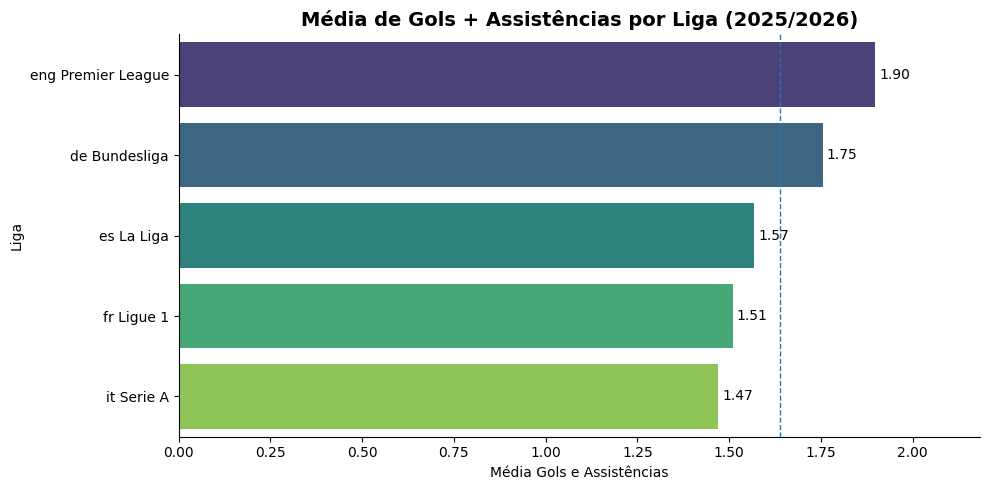

In [74]:
# Média de G+A por liga
ofensiveGA = (
    df.groupby("Comp")["G+A"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
 )
print(ofensiveGA)



# Visualizar dados (gráfico de barras horizontal)
plt.figure(figsize=(10,5))
ax = sns.barplot(data=ofensiveGA, x="G+A", y="Comp", hue="Comp", palette="viridis")
plt.title("Média de Gols + Assistências por Liga (2025/2026)", fontsize=14, weight="bold")
plt.xlabel("Média Gols e Assistências")
plt.ylabel("Liga")

# Linha vertical na média geral (contexto estatístico)
media_geral_GA = df["G+A"].mean()
plt.axvline(media_geral_GA, linestyle="--", linewidth=1)

# Labels nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

# Ajuste fino do limite do eixo
plt.xlim(0, ofensiveGA["G+A"].max() * 1.15)

# Remove bordas desnecessárias (visual mais limpo)
sns.despine()

plt.tight_layout()
plt.show()

* Qual liga é mais “criadora”?

                 Comp        KP
0  eng Premier League  7.494929
1          it Serie A  6.943359
2          es La Liga  6.737864
3       de Bundesliga  6.290541
4          fr Ligue 1  5.910448


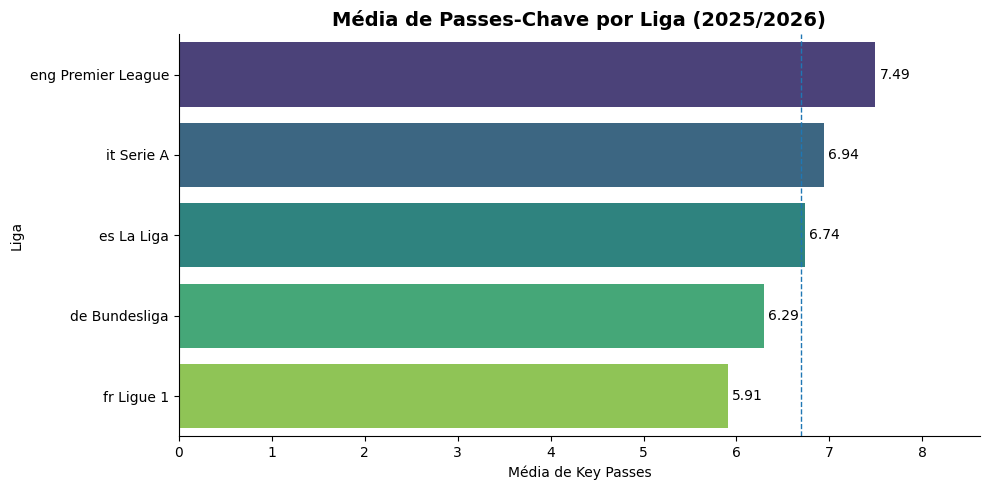

In [57]:
# Média de KP por liga
keyPasses = (
    df.groupby("Comp")["KP"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print(keyPasses)

# Visualizar dados (gráfico de barras horizontal)
plt.figure(figsize=(10,5))
ax = sns.barplot(data=keyPasses, x="KP", y="Comp", hue="Comp", palette="viridis")

plt.title("Média de Passes-Chave por Liga (2025/2026)", fontsize=14, weight="bold")
plt.xlabel("Média de Key Passes")
plt.ylabel("Liga")

# Linha vertical na média geral (contexto estatístico)
media_geral_KP = df["KP"].mean()
plt.axvline(media_geral_KP, linestyle="--", linewidth=1)

# Labels nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

# Ajuste fino do limite do eixo
plt.xlim(0, keyPasses["KP"].max() * 1.15)

# Remove bordas desnecessárias (visual mais limpo)
sns.despine()

plt.tight_layout()
plt.show()


*  Qual liga é mais jovem?

                 Comp        Age
0          es La Liga  26.390291
1          it Serie A  26.127451
2  eng Premier League  25.511156
3       de Bundesliga  25.412162
4          fr Ligue 1  24.808102


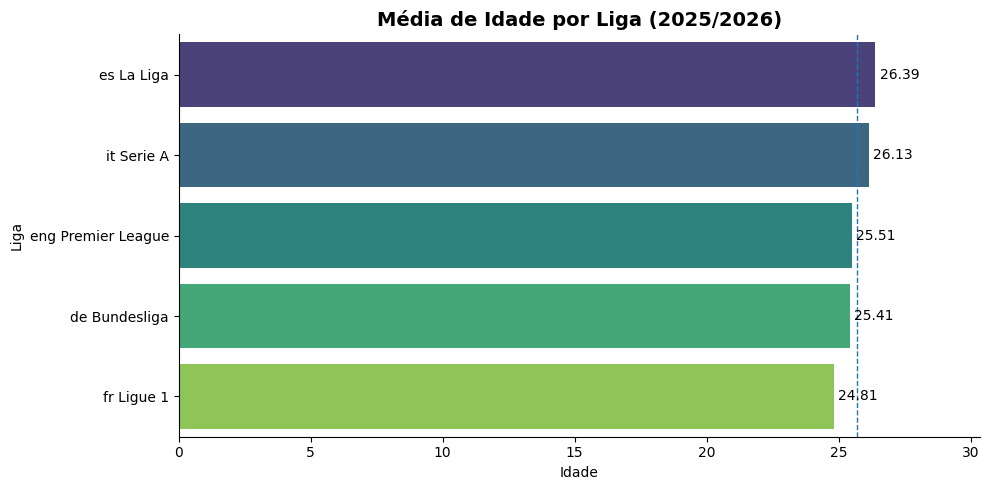

In [56]:
# Média de idade por liga
age = (
    df.groupby("Comp")["Age"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print(age)

# Visualizar dados (gráfico de barras horizontal)
plt.figure(figsize=(10,5))
ax = sns.barplot(data=age, x="Age", y="Comp", hue="Comp", palette="viridis")

plt.title("Média de Idade por Liga (2025/2026)", fontsize=14, weight="bold")
plt.xlabel("Idade")
plt.ylabel("Liga")

# Linha vertical na média geral (contexto estatístico)
media_geral_idade = df["Age"].mean()
plt.axvline(media_geral_idade, linestyle="--", linewidth=1)

# Labels nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

# Ajuste fino do limite do eixo
plt.xlim(0, age["Age"].max() * 1.15)

# Remove bordas desnecessárias (visual mais limpo)
sns.despine()

plt.tight_layout()
plt.show()

2 - Análise por Posição

 - Confirmação dos papéis táticos esperados

In [76]:
# Agrupamento por media em estatistica gerais
pos_stats = (
    df.groupby("Pos")[["Gls", "Ast", "G+A", "KP", "Tkl+Int"]]
    .mean()
    .reset_index()
)

pos_stats

,Pos,Gls,Ast,G+A,KP,Tkl+Int
0,DF,0.381208,0.430872,0.812081,4.697987,24.473826
1,"DF,FW",0.526316,0.815789,1.342105,8.342105,23.684211
2,"DF,MF",0.500000,0.775510,1.275510,7.551020,23.224490
3,FW,2.235135,0.910811,3.145946,7.181081,7.337838
4,"FW,DF",0.950000,0.700000,1.650000,6.600000,9.600000
5,"FW,MF",1.798246,0.951754,2.750000,9.267544,11.631579
6,GK,0.000000,0.040000,0.040000,0.440000,0.500000
7,MF,0.841699,0.731660,1.573359,8.308880,22.610039
8,"MF,DF",0.602740,0.780822,1.383562,7.301370,19.041096
9,"MF,FW",1.373057,0.994819,2.367876,9.963731,14.409326


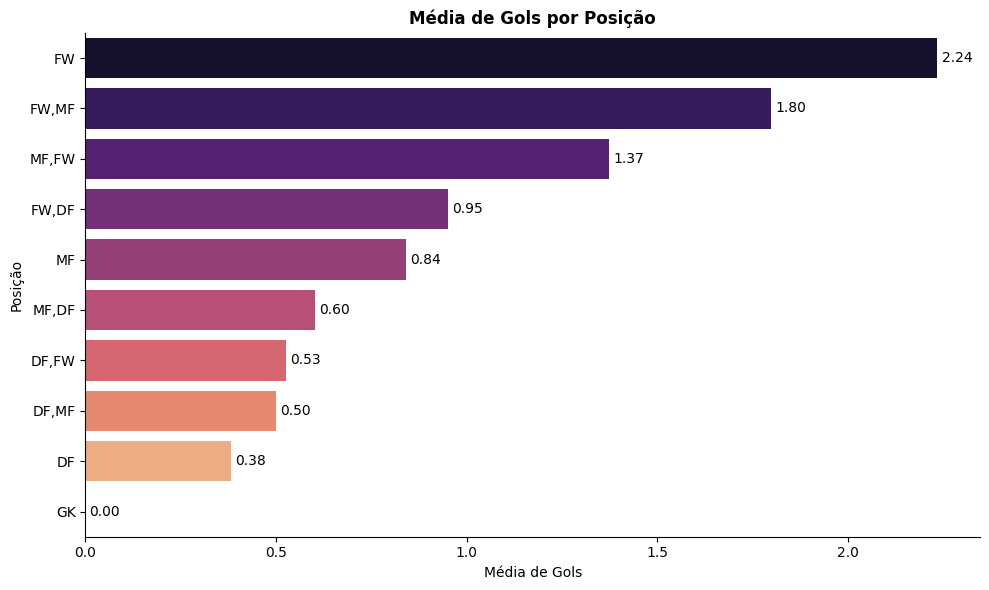

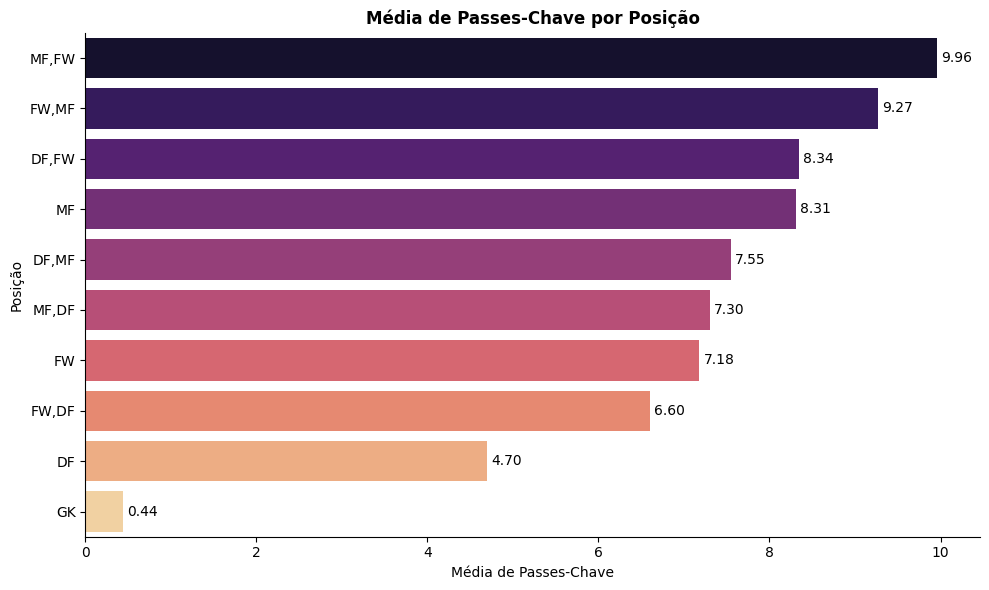

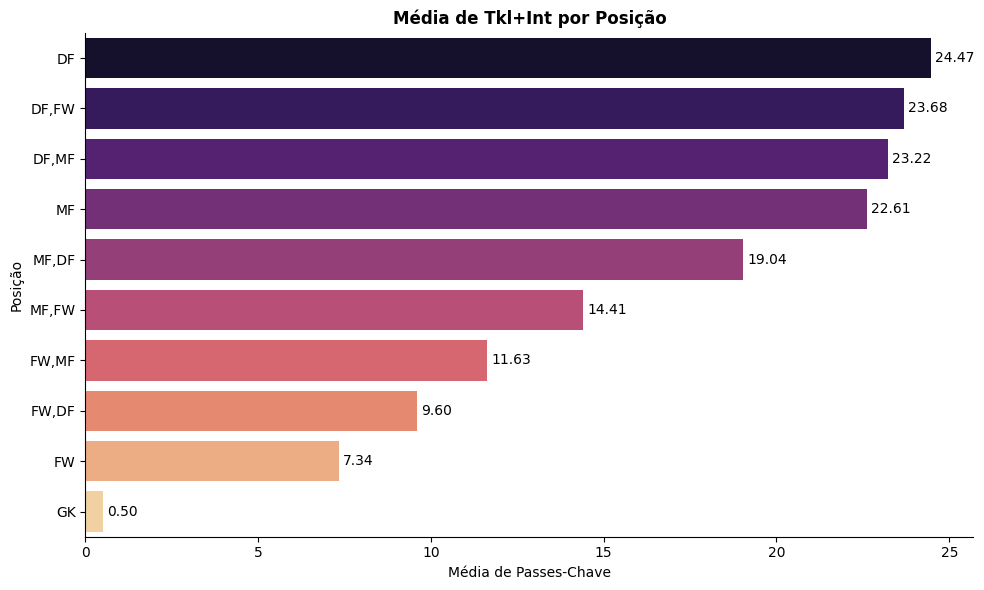

In [118]:
# Média de GOLS por Posição
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=pos_stats.sort_values("Gls", ascending=False),
    x="Gls",
    y="Pos",
    hue="Pos",  
    palette="magma"
)

plt.title("Média de Gols por Posição", weight="bold")
plt.xlabel("Média de Gols")
plt.ylabel("Posição")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

# Média de KP por Posição
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=pos_stats.sort_values("KP", ascending=False),
    x="KP",
    y="Pos",
    hue="Pos", 
    palette="magma"
)

plt.title("Média de Passes-Chave por Posição", weight="bold")
plt.xlabel("Média de Passes-Chave")
plt.ylabel("Posição")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

# Média de TLK+INT por Posição
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=pos_stats.sort_values("Tkl+Int", ascending=False),
    x="Tkl+Int",
    y="Pos",
    hue="Pos", 
    palette="magma"
)

plt.title("Média de Tkl+Int por Posição", weight="bold")
plt.xlabel("Média de Passes-Chave")
plt.ylabel("Posição")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

A análise por posição confirma o papel tático esperado no futebol moderno. 
 - Atacantes apresentam a maior média de gols, refletindo sua função primária de finalização
 - Meio-campistas lideram em passes-chave (KP), indicando maior participação na construção ofensiva. 
 - Defensores concentram maior média de Tkl+Int, reforçando seu papel na recuperação de bola.

Identificação de posições mais versáteis

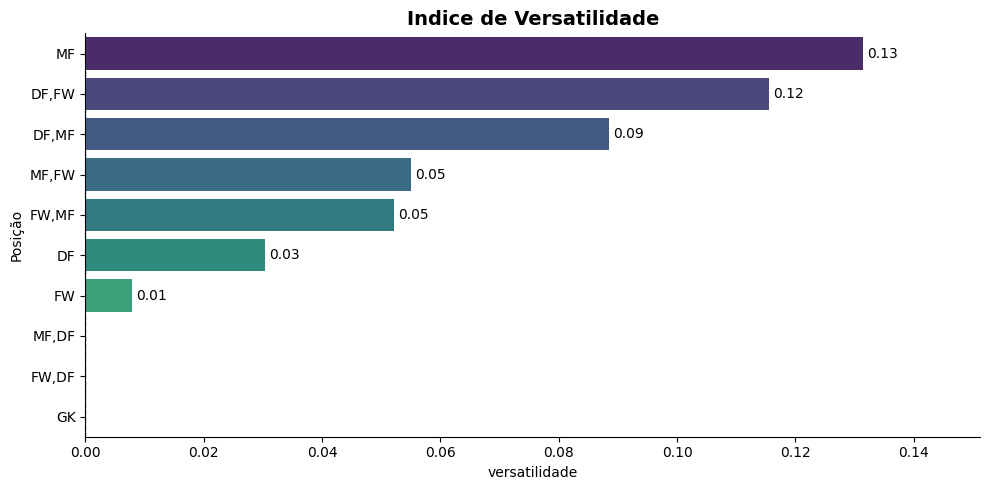

In [102]:
# Padronizar métricas ofensivo e defensivo na mesma escala estatística.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[["G+A", "Tkl+Int"]] = scaler.fit_transform(df[["G+A", "Tkl+Int"]])


# Criar índice de versatilidade
## Versatilidade = média dos valores padronizados ofensivo + defensivo

df_scaled["Indice_Versatilidade"] = (
    df_scaled["G+A"] + df_scaled["Tkl+Int"]
) / 2

## Média por posição

versatilidade_pos = (
    df_scaled.groupby("Pos")["Indice_Versatilidade"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Visualizar dados (gráfico de barras horizontal)
plt.figure(figsize=(10,5))
ax = sns.barplot(data=versatilidade_pos, x="Indice_Versatilidade", y="Pos", hue="Pos", palette="viridis")

plt.title("Indice de Versatilidade", fontsize=14, weight="bold")
plt.xlabel("versatilidade")
plt.ylabel("Posição")

# Linha vertical na média geral (contexto estatístico)
versatilidade = df_scaled["Indice_Versatilidade"].mean()
plt.axvline(versatilidade, linestyle="--", linewidth=1)

# Labels nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

# Ajuste fino do limite do eixo
plt.xlim(0, versatilidade_pos["Indice_Versatilidade"].max() * 1.15)

# Remove bordas desnecessárias (visual mais limpo)
sns.despine()

plt.tight_layout()
plt.show()

A análise do índice combinado ofensivo-defensivo indica que meio-campistas apresentam maior equilíbrio estatístico entre produção ofensiva (G+A) e ações defensivas (Tkl+Int). 

Diferentemente dos atacantes, que concentram sua contribuição no aspecto ofensivo, e dos defensores, que se destacam majoritariamente na recuperação de bola.

Os meio-campistas demonstram perfil mais distribuído entre as duas dimensões, sugerindo maior versatilidade funcional dentro do modelo de jogo.

3 - Correlação de métricas

In [ ]:
## Diferentes dimensões do jogo.

# Finalização → Gls 
# Criação → Ast 
# Criatividade → KP 
# Defesa → Tkl+Int

features = df[["Gls", "Ast", "KP", "Tkl+Int"]]

In [105]:
# Agora todas as métricas estão comparáveis.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

In [ ]:
# Algoritmo agora descobriu grupos estatísticos de jogadores.

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(scaled)

              Gls       Ast         KP    Tkl+Int
Cluster                                          
0        0.316875  0.182756   2.373618   6.468681
1        5.164179  1.422886  13.910448  15.044776
2        0.718153  0.523885   7.796178  37.740446
3        1.761134  3.105263  21.748988  30.052632


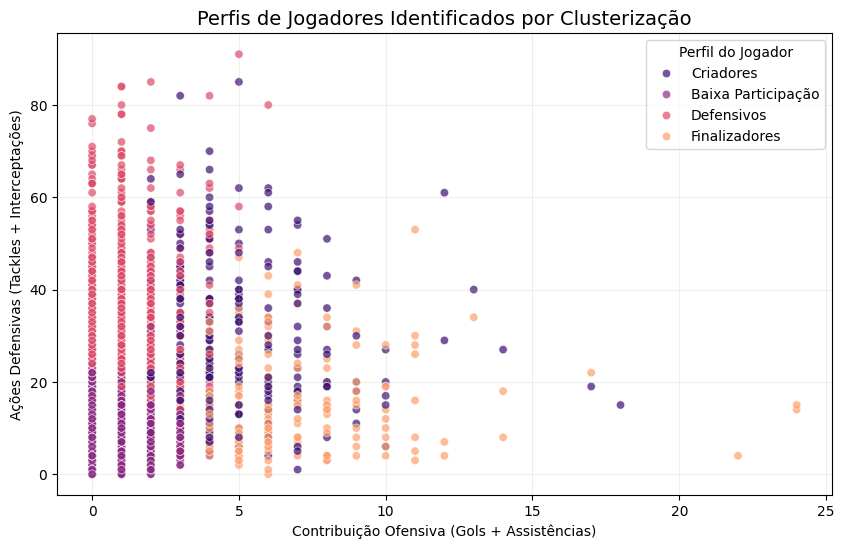

In [151]:
cluster_profile = df.groupby("Cluster")[["Gls","Ast","KP","Tkl+Int"]].mean()

print(cluster_profile)

cluster_names = {
    0: "Baixa Participação",
    1: "Finalizadores",
    2: "Defensivos",
    3: "Criadores"
}

df["Perfil"] = df["Cluster"].map(cluster_names)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="G+A",
    y="Tkl+Int",
    hue="Perfil",
    palette="magma",
    alpha=0.7
)

plt.title("Perfis de Jogadores Identificados por Clusterização", fontsize=14)
plt.xlabel("Contribuição Ofensiva (Gols + Assistências)")
plt.ylabel("Ações Defensivas (Tackles + Interceptações)")
plt.legend(title="Perfil do Jogador")

plt.grid(alpha=0.2)

plt.show()

A visualização demonstra que jogadores com maior contribuição ofensiva tendem a apresentar menor volume defensivo, enquanto defensores apresentam alta intensidade defensiva com baixa produção ofensiva. Essa segmentação permite compreender diferentes papéis táticos dentro das equipes

* Correlação entre KP e G+A (estatística)

           KP       G+A
KP   1.000000  0.672779
G+A  0.672779  1.000000


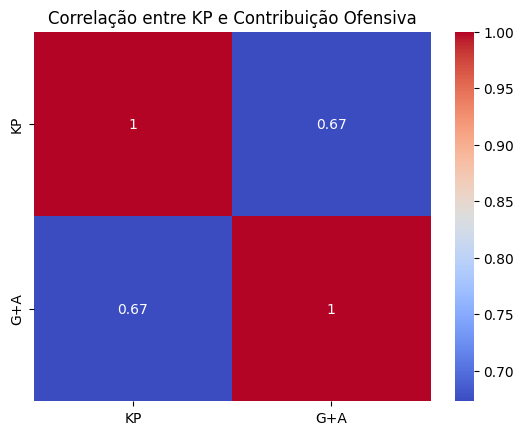

In [133]:
corr = df[["KP","G+A"]].corr()
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df[["KP","G+A"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlação entre KP e Contribuição Ofensiva")
plt.show()

#| Correlação  | Significado |
#|   0  – 0.3  |   fraca     |
#|  0.3 – 0.6  |  moderada   |
#|  0.6 – 1    |   forte     |


Observou-se uma correlação positiva moderada (r = 0.67) entre passes chave (KP) e contribuição ofensiva (G+A). Isso sugere que jogadores envolvidos na criação de chances também tendem a participar diretamente de gols, embora os dois papéis não sejam totalmente equivalentes.

5 - Performance por Idade (análise temporal)

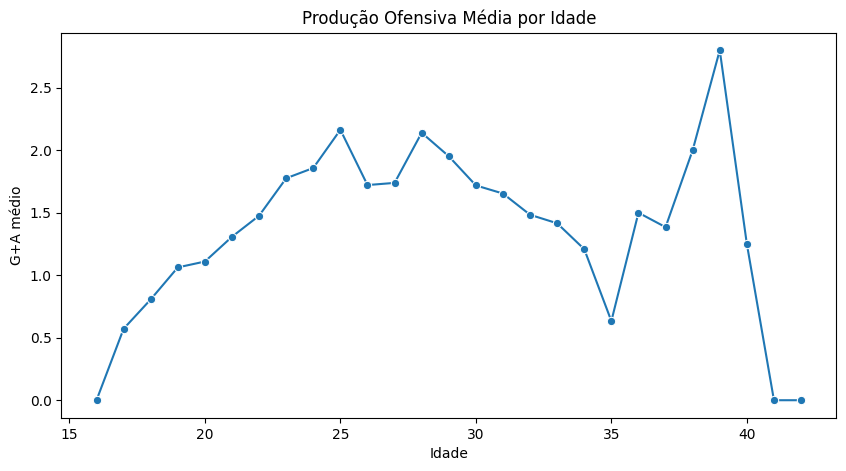

Age    39.0
G+A     2.8
Name: 23, dtype: float64


In [128]:
# Agrupamos por idade.
age_perf = df.groupby("Age")["G+A"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=age_perf,
    x="Age",
    y="G+A",
    marker="o"
)

plt.title("Produção Ofensiva Média por Idade")
plt.xlabel("Idade")
plt.ylabel("G+A médio")

plt.show()

age_peak = age_perf.loc[age_perf["G+A"].idxmax()]

print(age_peak)

A produção ofensiva média aumenta progressivamente desde o início da carreira e atinge seu pico aproximadamente entre 24 e 29 anos, período em que jogadores combinam maturidade tática, pico físico e maior tempo de jogo.

Observa-se tambem um valor extremo aos 39 anos, possivelmente causado por jogadores fora da curva de performance, indicando a presença de outliers na amostra.

Verificar se ligas possuem estilos diferentes (análise contextual)

                         Gls       Ast        KP    Tkl+Int
Comp                                                       
de Bundesliga       1.015766  0.738739  6.290541  15.159910
eng Premier League  1.141988  0.756592  7.494929  21.427992
es La Liga          0.920388  0.648544  6.737864  17.875728
fr Ligue 1          0.893390  0.616205  5.910448  15.895522
it Serie A          0.873047  0.597656  6.943359  17.519531


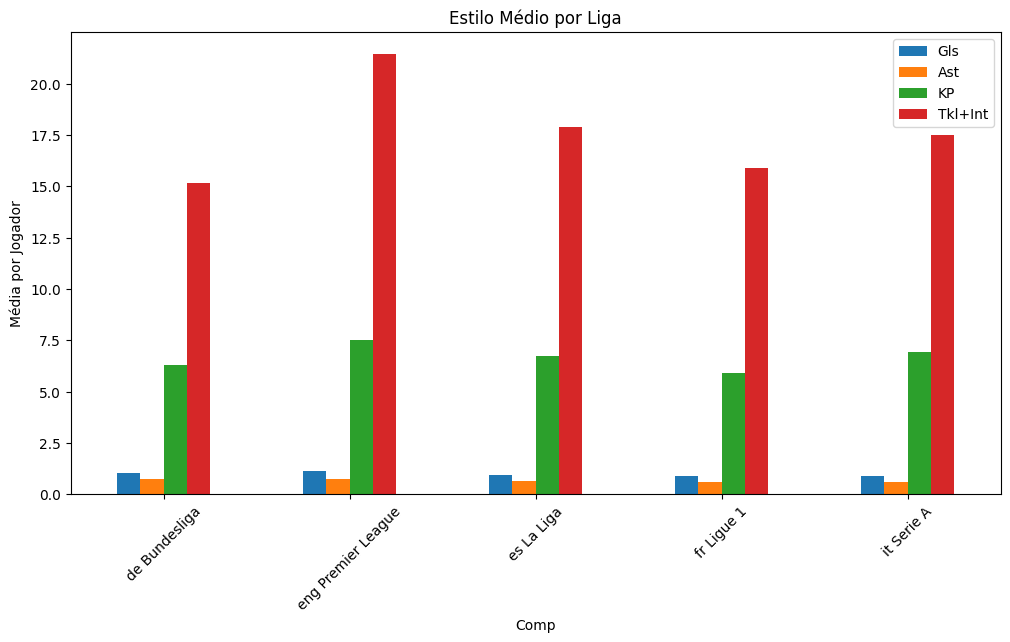

In [130]:
# mais gols - mais criação - mais defesa

# Agrupamos por liga
league_style = df.groupby("Comp")[["Gls","Ast","KP","Tkl+Int"]].mean()

print(league_style)

league_style.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Estilo Médio por Liga")
plt.ylabel("Média por Jogador")
plt.xticks(rotation=45)

plt.show()

Bundesliga
- Bons números ofensivos
- Defesa moderada
- Liga historicamente ofensiva com alto volume de transições.

Premier League 
- Maior média de KP
- Mais ações defensivas (Tkl+Int)
- Liga com alto ritmo e intensidade física, exigindo participação ofensiva e defensiva.

La Liga
- Bons KP
- Defensivo moderado
- Perfil técnico e criativo, mas menos físico.

Ligue 1
- Menores KP
- Defesa mais baixa
- Menor volume criativo médio.

Serie A
- KP relativamente alto
- Defesa moderada
- equilíbrio entre criação e organização tática.

Comparações entre ligas também indicaram diferenças de estilo de jogo. A Premier League apresentou maiores médias de ações defensivas e criação de jogadas, refletindo seu ritmo intenso, enquanto ligas como La Liga e Serie A demonstraram maior equilíbrio entre criação e organização tática.

7 - Índice de performance (Top 10)

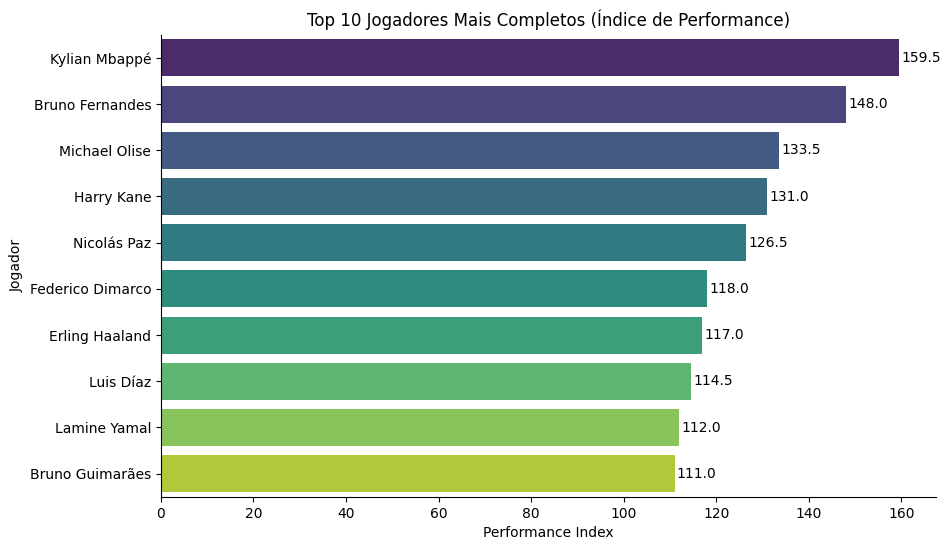

In [153]:
# gols valem mais
# assistências logo depois
# criação pesa moderadamente
# defesa entra como complemento

df["Performance_Index"] = (
    df["Gls"] * 4 +
    df["Ast"] * 3 +
    df["KP"] * 1.5 +
    df["Tkl+Int"] * 0.5
)

top10 = df.sort_values("Performance_Index", ascending=False).head(10)
#print(top10[["Player","Pos","Comp","Performance_Index","Gls","Ast","KP","Tkl+Int"]])

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Performance_Index",
    y="Player",
    hue="Player",
    palette="viridis"
)

plt.title("Top 10 Jogadores Mais Completos (Índice de Performance)")
plt.xlabel("Performance Index")
plt.ylabel("Jogador")

for i, v in enumerate(top10["Performance_Index"]):
    plt.text(v + 0.5, i, f"{v:.1f}", va="center")

sns.despine()

plt.show()


Para avaliar jogadores de forma mais holística, foi criado um Índice de Performance, combinando gols, assistências, passes chave e ações defensivas com pesos heurísticos. O ranking resultante evidencia jogadores que contribuem em múltiplas fases do jogo, não apenas na finalização.

* Informações do melhor jogador

In [143]:
# Melhor jogador pelo seu índice
best_player = df.sort_values("Performance_Index", ascending=False).iloc[0]

player_name = best_player["Player"]
player_pos = best_player["Pos"]
print(player_name, player_pos)

metrics = ["Gls","Ast","KP","Tkl+Int"]
pos_avg = df[df["Pos"] == player_pos][metrics].mean()
print(pos_avg)

Kylian Mbappé FW
Gls        2.235135
Ast        0.910811
KP         7.181081
Tkl+Int    7.337838
dtype: float64


In [148]:
# Normalizar os dados usando Min-Max Scaling. Cada métrica vai de 0 a 1 dentro do dataset
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[metrics])

df_scaled = df.copy()
df_scaled[metrics] = scaled

player_scaled = df_scaled.loc[best_player.name, metrics].values
pos_scaled = scaler.transform(pos_avg.to_frame().T)[0]


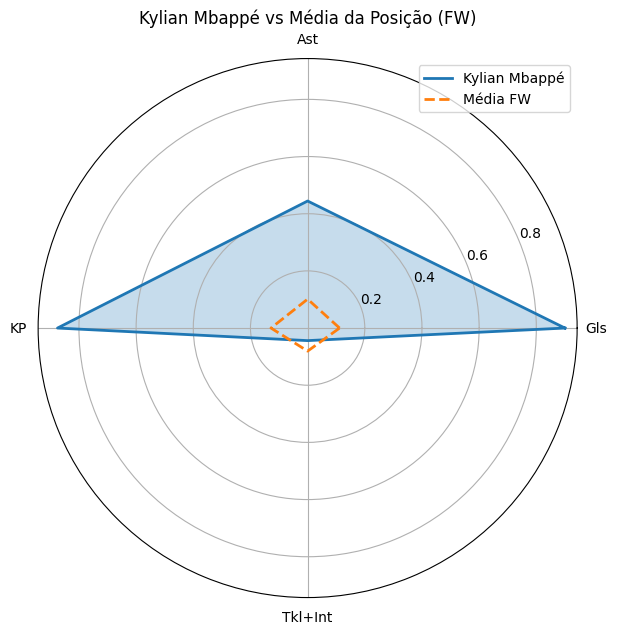

In [149]:
import numpy as np
import matplotlib.pyplot as plt

labels = metrics

player_values = np.append(player_scaled, player_scaled[0])
pos_values = np.append(pos_scaled, pos_scaled[0])

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.append(angles, angles[0])

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

ax.plot(angles, player_values, linewidth=2, label=player_name)
ax.fill(angles, player_values, alpha=0.25)

ax.plot(angles, pos_values, linewidth=2, linestyle="--", label=f"Média {player_pos}")

ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)

plt.title(f"{player_name} vs Média da Posição ({player_pos})")

plt.legend(loc="upper right")

plt.show()